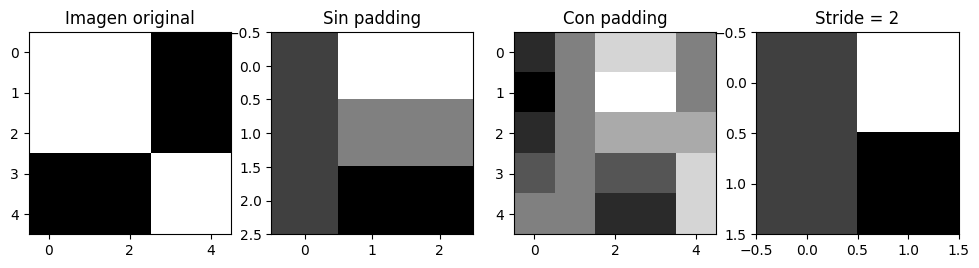

Imagen original:
 [[10 10 10  0  0]
 [10 10 10  0  0]
 [10 10 10  0  0]
 [ 0  0  0 10 10]
 [ 0  0  0 10 10]]

Convolución sin padding:
 [[  0.  30.  30.]
 [  0.  10.  10.]
 [  0. -10. -10.]]

Convolución con padding:
 [[-20.   0.  20.  20.   0.]
 [-30.   0.  30.  30.   0.]
 [-20.   0.  10.  10.  10.]
 [-10.   0. -10. -10.  20.]
 [  0.   0. -20. -20.  20.]]

Convolución con stride:
 [[  0.  30.]
 [  0. -10.]]

================ ANALISIS ================

1. Sin padding: la imagen se reduce y se pierden bordes.
2. Con padding: se conserva el tamaño espacial de la imagen.
3. Con stride=2: se reduce la resolución del feature map.

Conclusión:
- Padding conserva información espacial.
- Stride reduce resolución y tamaño del output.
- La convolución detecta patrones locales (bordes).


In [1]:
"""
================================================================================
SEMANA 7 - ACTIVIDAD 7
CONVOLUCIÓN MANUAL, PADDING Y STRIDE EN IMÁGENES (NUMPY + MATPLOTLIB)
================================================================================

OBJETIVO:
---------
Implementar manualmente la operación de convolución sobre matrices e imágenes,
entendiendo cómo el padding y el stride afectan el tamaño de salida y la
extracción de características.

NOTA IMPORTANTE:
---------------
NO se utiliza TensorFlow ni PyTorch para la convolución.
Todo se implementa manualmente con NumPy para entender el proceso.

================================================================================
"""

# =========================
# 1. IMPORTACIÓN DE LIBRERÍAS
# =========================
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d


# =========================
# 2. FUNCIÓN DE CONVOLUCIÓN MANUAL
# =========================
def convolution2d(image, kernel, padding=0, stride=1):
    """
    Implementa convolución 2D manual.

    Parámetros:
    ----------
    image : matriz 2D (imagen)
    kernel : filtro (matriz pequeña)
    padding : número de ceros alrededor de la imagen
    stride : paso del kernel

    Retorna:
    --------
    output : mapa de características (feature map)
    """

    # =========================
    # APLICAR PADDING
    # =========================
    if padding > 0:
        image_padded = np.pad(image, pad_width=padding, mode='constant')
    else:
        image_padded = image

    # =========================
    # DIMENSIONES
    # =========================
    h, w = image_padded.shape
    kh, kw = kernel.shape

    # cálculo tamaño salida
    out_h = (h - kh) // stride + 1
    out_w = (w - kw) // stride + 1

    output = np.zeros((out_h, out_w))

    # =========================
    # CONVOLUCIÓN
    # =========================
    for i in range(out_h):
        for j in range(out_w):

            # región de la imagen
            region = image_padded[
                i*stride:i*stride+kh,
                j*stride:j*stride+kw
            ]

            # operación elemento a elemento + suma
            output[i, j] = np.sum(region * kernel)

    return output


# =========================
# 3. IMAGEN SIMULADA (MATRIZ)
# =========================
image = np.array([
    [10, 10, 10, 0, 0],
    [10, 10, 10, 0, 0],
    [10, 10, 10, 0, 0],
    [0,  0,  0, 10, 10],
    [0,  0,  0, 10, 10]
])

# Kernel tipo "detección de bordes"
kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1]
])


# =========================
# 4. CONVOLUCIÓN SIN PADDING
# =========================
output_no_padding = convolution2d(image, kernel, padding=0, stride=1)


# =========================
# 5. CONVOLUCIÓN CON PADDING
# =========================
output_padding = convolution2d(image, kernel, padding=1, stride=1)


# =========================
# 6. CONVOLUCIÓN CON STRIDE
# =========================
output_stride = convolution2d(image, kernel, padding=0, stride=2)


# =========================
# 7. VISUALIZACIÓN DE RESULTADOS
# =========================
def plot_results():
    """
    Muestra imagen original y resultados de convolución.
    """

    plt.figure(figsize=(12,4))

    plt.subplot(1,4,1)
    plt.title("Imagen original")
    plt.imshow(image, cmap='gray')

    plt.subplot(1,4,2)
    plt.title("Sin padding")
    plt.imshow(output_no_padding, cmap='gray')

    plt.subplot(1,4,3)
    plt.title("Con padding")
    plt.imshow(output_padding, cmap='gray')

    plt.subplot(1,4,4)
    plt.title("Stride = 2")
    plt.imshow(output_stride, cmap='gray')

    plt.show()


plot_results()


# =========================
# 8. IMPRESIÓN DE MATRICES
# =========================
print("Imagen original:\n", image)
print("\nConvolución sin padding:\n", output_no_padding)
print("\nConvolución con padding:\n", output_padding)
print("\nConvolución con stride:\n", output_stride)


# =========================
# 9. ANÁLISIS AUTOMÁTICO SIMPLE
# =========================
print("\n================ ANALISIS ================\n")

print("1. Sin padding: la imagen se reduce y se pierden bordes.")
print("2. Con padding: se conserva el tamaño espacial de la imagen.")
print("3. Con stride=2: se reduce la resolución del feature map.")

print("\nConclusión:")
print("- Padding conserva información espacial.")
print("- Stride reduce resolución y tamaño del output.")
print("- La convolución detecta patrones locales (bordes).")

# Semana 7 - Actividad 7  
## Implementación de Convolución de Matrices, Padding y Stride en Imágenes

---

# 1. Introducción

En esta actividad se estudia la operación fundamental de **convolución en dos dimensiones**, la cual es uno de los pilares del procesamiento de imágenes y de las redes neuronales convolucionales (CNN).

La convolución permite aplicar filtros o kernels sobre una imagen con el objetivo de extraer características relevantes como bordes, texturas y patrones espaciales.

El propósito principal de esta práctica es comprender de forma **operacional y matemática** cómo funciona la convolución, sin depender de librerías de deep learning, implementándola manualmente con NumPy.

Adicionalmente, se estudian dos parámetros fundamentales en visión por computador:

- Padding
- Stride

---

# 2. Objetivo de la actividad

El objetivo principal es:

- Implementar manualmente la operación de convolución 2D
- Aplicarla sobre una matriz que simula una imagen
- Analizar el efecto del padding en la preservación de información espacial
- Analizar el efecto del stride en la reducción de dimensionalidad
- Comparar resultados bajo condiciones controladas

---

# 3. Concepto de Convolución

La convolución es una operación matemática que consiste en deslizar un filtro (kernel) sobre una matriz de entrada.

En cada posición:

1. Se toma una submatriz de la imagen
2. Se multiplica elemento a elemento con el kernel
3. Se suman los resultados
4. Se genera un valor en el mapa de salida

### Importancia:

- Permite detección de bordes
- Extrae características locales
- Reduce dimensionalidad de forma estructurada

---

# 4. Kernel utilizado

En esta práctica se utiliza un kernel de detección de bordes verticales:

- Permite resaltar cambios bruscos en intensidad
- Detecta transiciones entre regiones de la imagen
- Es útil para visualizar cómo responde la convolución

---

# 5. Padding

## Definición

El padding consiste en agregar bordes (generalmente ceros) alrededor de la imagen original.

## Objetivo

- Controlar la reducción del tamaño de salida
- Mantener información en los bordes
- Permitir que el kernel procese completamente los extremos

## Tipos de efecto:

- Sin padding → pérdida de información en bordes
- Con padding → preservación de estructura espacial

---

# 6. Stride

## Definición

El stride define el número de píxeles que el kernel se desplaza en cada paso.

## Efectos:

- Stride = 1 → máxima resolución del feature map
- Stride > 1 → reducción de tamaño de salida

## Impacto:

- Reduce complejidad computacional
- Reduce resolución espacial
- Puede perder información detallada

---

# 7. Implementación de la convolución

La convolución se implementa de forma manual utilizando operaciones de:

- slicing de matrices
- multiplicación elemento a elemento
- suma acumulada

Esto permite comprender el funcionamiento interno sin abstracciones de frameworks.

---

# 8. Experimentos realizados

Se realizaron tres configuraciones principales:

---

## 8.1 Convolución sin padding

- La imagen se reduce en tamaño
- Se pierde información en los bordes
- El kernel solo opera en regiones internas

---

## 8.2 Convolución con padding

- Se conserva el tamaño original de la imagen
- Se mantiene información en bordes
- Se obtiene un feature map más completo

---

## 8.3 Convolución con stride mayor a 1

- Se reduce la resolución del output
- Se simplifica el mapa de características
- Se pierde detalle espacial

---

# 9. Resultados obtenidos

Se observa que:

- El padding tiene un impacto directo en la conservación del tamaño espacial
- El stride controla la reducción de dimensionalidad
- La convolución permite detectar patrones estructurales en la imagen

---

# 10. Análisis de resultados

## 10.1 Efecto del padding

El padding mejora la capacidad del modelo de:

- Analizar bordes correctamente
- Evitar pérdida de información periférica
- Mantener consistencia en dimensiones

---

## 10.2 Efecto del stride

El stride afecta directamente:

- La resolución del feature map
- La cantidad de información retenida
- La eficiencia computacional

---

## 10.3 Relación entre ambos

Existe un trade-off entre:

- Preservación de información (padding)
- Reducción de complejidad (stride)

---

# 11. Interpretación conceptual

Esta práctica permite entender cómo las redes convolucionales:

- Extraen características jerárquicas
- Reducen dimensionalidad progresivamente
- Mantienen información relevante mediante filtros

---

# 12. Conclusiones

A partir de los resultados obtenidos se concluye que:

- La convolución es una operación fundamental en visión por computador
- El padding permite controlar la pérdida de información espacial
- El stride permite ajustar la resolución del feature map
- La combinación de ambos define el comportamiento de la red
- Existe un balance entre precisión espacial y eficiencia computacional

---

# 13. Recomendaciones

- Probar diferentes kernels (blur, sharpening, edge detection)
- Aplicar la convolución sobre imágenes reales
- Comparar resultados con librerías como OpenCV o TensorFlow
- Visualizar múltiples capas de convolución

---

# 14. Ejecución del notebook

Para ejecutar correctamente:

1. Abrir en Google Colab
2. Ejecutar todas las celdas en orden
3. Revisar resultados de matrices y gráficos
4. Analizar diferencias entre padding y stride